<a href="https://colab.research.google.com/github/zlwym/Mann_Zoe_LabTask/blob/main/labtask02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


# **Loading Dataset**

In [63]:
import pandas as pd

In [64]:
df = pd.read_csv("grades_crpt.csv")

In [65]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


# **Dataset Exploration**

The data seems to be full of null (missing, NaN) values, maybe from missing assignments.

There are also some negative values and values above 100 (which may or may not be due to bonus points).

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB


The final exam and user ID columns are the only ones with no null values.

All assignments, columns A1, A2, A3, A4, A5, A6, and A7, have missing values.

A1: 29 missing values

A2: 25 missing values

A3: 24 missing values

A4: 9 missing values

A5: 25 missing values

A6: 19 missing values

A7: 10 missing values

In [67]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


The minimum values for A1, A2, A3, A4, and A6 are negative values which do not make sense for the context of this dataset.

There are also maximums of more than 100 on A1, A3, A5, and A7 when there were only bonus marks on A2, A4, and A6. There should only be values over 100 in columns A2, A4, and A6.

In [68]:
neg = df[["A1", "A2", "A3", "A4", "A5", "A6", "A7", "Final_Exam"]].lt(0).any(axis=1)
display(df[neg])

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
9,129.9,76.8,-5.3,93.8,100.0,90.0,12.2,65.3,U010
12,54.2,92.9,-69.3,81.2,NaN,183.6,82.5,71.9,U013
26,NaN,NaN,-1.7,88.8,55.0,20.0,77.5,33.1,U027
44,-4.5,148.9,100.0,98.8,92.0,NaN,91.5,82.5,U045
52,41.7,58.9,-70.1,88.8,80.0,70.0,71.9,31.9,U053
67,90.0,100.0,83.0,-21.6,97.0,100.0,81.2,67.5,U068
76,83.3,64.3,55.0,78.8,100.0,-17.0,78.8,70.9,U077
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1,U083


lt() helps check for values in the dataframe that are less than a specified value and returns True or False. any() helps return a value for each column. This helps isolate rows with negative values. They appear to be data input errors and are most likely meant to be positive.

In [69]:
overHundred = df[["A1", "A2", "A3", "A4", "A5", "A6", "A7", "Final_Exam"]].gt(100).any(axis=1)
display(df[overHundred])

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
5,100.0,92.9,100.0,96.2,NaN,80.0,110.5,97.5,U006
6,95.8,64.3,63.0,175.8,85.0,76.0,83.8,64.4,U007
7,168.9,100.0,40.0,95.0,100.0,100.0,NaN,40.6,U008
9,129.9,76.8,-5.3,93.8,100.0,90.0,12.2,65.3,U010
12,54.2,92.9,-69.3,81.2,NaN,183.6,82.5,71.9,U013
14,79.2,100.0,100.0,86.2,NaN,60.0,142.1,80.0,U015
15,168.1,64.3,NaN,87.5,90.0,80.0,75.0,46.6,U016
16,174.6,57.1,149.2,87.5,NaN,70.0,80.0,65.3,U017
17,NaN,91.1,NaN,101.2,98.0,100.0,85.6,68.8,U018
21,79.2,114.3,95.0,90.0,95.0,NaN,90.0,64.1,U022


gt() helps check for values in the dataframe that are more than a specified value. This helps isolate rows with values over 100. There should only be values over 100 for A2, A4, and A6.

# **Checking Correlations**

In [70]:
import seaborn as sns

#Columns
numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']

#Correlation matrix
corr_matrix = df[numeric_cols].corr()

print(corr_matrix.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.14  0.36  0.30  0.24  0.23 -0.02        0.21
A2         -0.14  1.00  0.21 -0.03  0.01  0.36  0.03        0.28
A3          0.36  0.21  1.00  0.19  0.19 -0.03  0.15        0.28
A4          0.30 -0.03  0.19  1.00  0.04  0.15  0.22        0.40
A5          0.24  0.01  0.19  0.04  1.00  0.24  0.03        0.02
A6          0.23  0.36 -0.03  0.15  0.24  1.00  0.15        0.25
A7         -0.02  0.03  0.15  0.22  0.03  0.15  1.00        0.38
Final_Exam  0.21  0.28  0.28  0.40  0.02  0.25  0.38        1.00


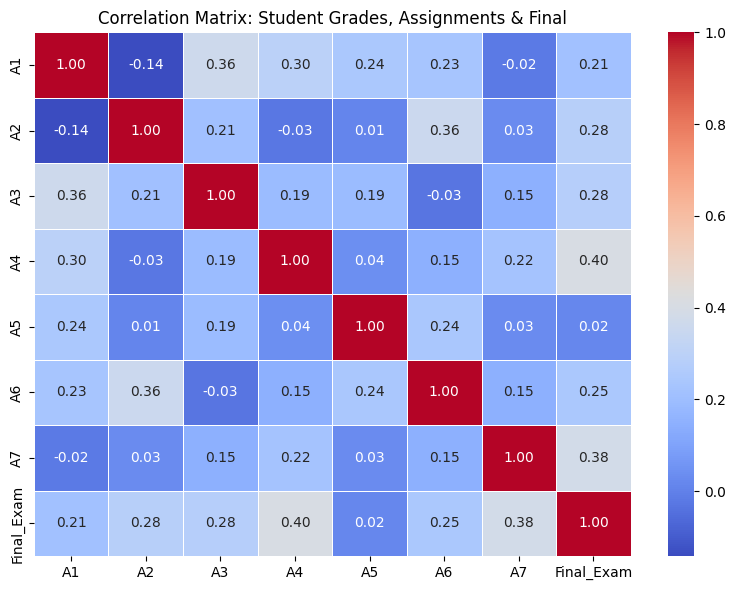

In [71]:
import matplotlib.pyplot as plt

#Using pyplot to create and display a correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Student Grades, Assignments & Final')
plt.tight_layout()
plt.show()

There isn't one single assignment that closely correlates to the scores of the final exam. The two assignment outcomes that most closely correlate to the final exam are A4 (correlation coefficient of 0.40) and A7 (correlation coefficient of 0.38). A4 and A7 had the least missing values as well which is another reason why they might have stronger correlation to the final exam results.

The assignment that is the least related to the outcome of the final exam is A5 (correlation coefficient of 0.02).

# **Checking for Missing Values**

In [72]:
print(df.isnull().sum())

A1            29
A2            25
A3            24
A4             9
A5            25
A6            19
A7            10
Final_Exam     0
user_id        0
dtype: int64


This tells us how many missing values there are in each column. Everyone took and received a score for the final exam. A1 is missing the most values.

In [73]:
missing_values = df[["A1", "A2", "A3", "A4", "A5", "A6", "A7", "Final_Exam"]].isnull().any(axis=1)
display(df[missing_values])

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005
5,100.0,92.9,100.0,96.2,NaN,80.0,110.5,97.5,U006
...,...,...,...,...,...,...,...,...,...
81,NaN,NaN,NaN,56.2,NaN,29.2,60.0,57.5,U082
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1,U083
83,79.2,NaN,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,NaN,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


Printing out every row with missing values, we can see that there are 73 total rows with missing values.

# **Handling Missing Values**

In [74]:
#Dropping null values
dropNull = df.copy()
dropNull = dropNull.dropna()
display(dropNull)

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
6,95.8,64.3,63.0,175.8,85.0,76.0,83.8,64.4,U007
9,129.9,76.8,-5.3,93.8,100.0,90.0,12.2,65.3,U010
11,79.2,57.1,64.0,68.8,90.0,72.0,68.8,28.4,U012
30,83.3,100.0,60.0,183.1,90.0,70.0,78.8,49.1,U031
34,81.7,92.9,82.0,95.7,95.0,82.0,70.6,54.4,U035
52,41.7,58.9,-70.1,88.8,80.0,70.0,71.9,31.9,U053
53,66.7,57.1,30.0,37.5,90.0,60.0,77.5,49.4,U054
54,95.8,100.0,152.2,95.0,100.0,100.0,12.3,78.4,U055
59,91.7,92.9,98.0,98.2,7.7,88.0,81.2,81.2,U060


In [77]:
#Mean imputation

meanImpute = df.copy()
meanImpute[numeric_cols] = meanImpute[numeric_cols].fillna(meanImpute[numeric_cols].mean())
display(meanImpute)

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,83.67193,81.096721,30.000000,75.0,90.000000,65.000000,50.600000,68.8,U001
1,100.00000,81.096721,68.174194,92.5,100.000000,100.000000,84.400000,50.3,U002
2,75.00000,69.600000,68.174194,86.2,100.000000,74.437313,78.130263,67.8,U003
3,25.00000,78.600000,40.000000,0.0,50.000000,30.700000,0.000000,0.0,U004
4,0.00000,81.096721,0.000000,0.0,89.645902,74.437313,78.130263,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,83.67193,81.096721,68.174194,56.2,89.645902,29.200000,60.000000,57.5,U082
82,87.50000,-30.600000,70.000000,174.8,91.000000,74.437313,146.400000,64.1,U083
83,79.20000,81.096721,60.000000,27.5,50.000000,60.000000,75.000000,45.6,U084
84,83.67193,0.000000,85.000000,100.0,55.000000,0.000000,0.000000,30.6,U085


In [78]:
#Median imputation

medianImpute = df.copy()
medianImpute[numeric_cols] = medianImpute[numeric_cols].fillna(medianImpute[numeric_cols].median())
display(medianImpute)

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,87.5,91.1,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,91.1,80.0,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,80.0,86.2,100.0,80.0,80.0,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,91.1,0.0,0.0,95.0,80.0,80.0,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,87.5,91.1,80.0,56.2,95.0,29.2,60.0,57.5,U082
82,87.5,-30.6,70.0,174.8,91.0,80.0,146.4,64.1,U083
83,79.2,91.1,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,87.5,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


As of now, removing all the null values leaves us with 13 rows, significantly reducing the sample size. This doesn't give us much data to work with. Since the data has not been cleaned yet and I haven't looked at outliers, the median seems to work the best. The mean is skewed by the extreme values.

In [83]:
for label, frame in [('Mean', meanImpute), ('Median', medianImpute), ('Droped Null', dropNull)]:
    corr = frame[numeric_cols].corr()['Final_Exam']
    print(f"{label}")
    print(corr.round(2))

Mean
A1            0.18
A2            0.24
A3            0.25
A4            0.38
A5            0.01
A6            0.21
A7            0.35
Final_Exam    1.00
Name: Final_Exam, dtype: float64
Median
A1            0.18
A2            0.22
A3            0.26
A4            0.39
A5            0.02
A6            0.21
A7            0.35
Final_Exam    1.00
Name: Final_Exam, dtype: float64
Droped Null
A1            0.79
A2            0.29
A3            0.42
A4            0.34
A5            0.14
A6            0.34
A7            0.17
Final_Exam    1.00
Name: Final_Exam, dtype: float64


Looking at correlation with the final exam, the mean and median methods give very similar results. While the mean has a better correlation coefficient for A2, the median method was very slightly better overall. Of course, dropping the null values gives the best results overall since the final exam column contained no null values, but this doesn't give great data since most of the rows have been dropped.

# **Check for Outliers**

The values above 100 for A1, A3, A5, and A7 appear abnormally high, and there were no bonus points available for these assignments. I will assume these are data entry errors and subtract 100 from these values in columns A1, A3, A5, and A7. Values above 100 in A2, A4, and A6 will remain the same and I will assume there were bonus points earned. Bonus points are in points and not percentage so I can't assume each assignment was out of 100.

I will simply turn negative values positive, assuming they are also data entry errors. There are also no negative values lesser than -100.

In [90]:
#Make a copy to clean
cleaned = df.copy()

#Subtract 100 from values over 100 for A1, A3, A5, and A7
oddAssignments = ['A1', 'A3', 'A5', 'A7']
for col in oddAssignments:
  x = cleaned[col] > 100
  cleaned.loc[x, col] = cleaned.loc[x, col] - 100
  print(f"{col}: {x.sum()} Greater than 100 values corrected")
  print(f"{col}: {cleaned[col].max()} New maximum value")

print("\n")

#Make all negative values positive
for col in numeric_cols:
  x = cleaned[col] < 0
  cleaned.loc[x, col] = cleaned.loc[x, col] * -1
  print(f"{col}: {x.sum()} Less than 0 values corrected")
  print(f"{col}: {cleaned[col].min()} New minimum value")

A1: 5 Greater than 100 values corrected
A1: 100.0 New maximum value
A3: 3 Greater than 100 values corrected
A3: 100.0 New maximum value
A5: 5 Greater than 100 values corrected
A5: 100.0 New maximum value
A7: 7 Greater than 100 values corrected
A7: 98.8 New maximum value


A1: 1 Less than 0 values corrected
A1: 0.0 New minimum value
A2: 1 Less than 0 values corrected
A2: 0.0 New minimum value
A3: 4 Less than 0 values corrected
A3: 0.0 New minimum value
A4: 1 Less than 0 values corrected
A4: 0.0 New minimum value
A5: 0 Less than 0 values corrected
A5: 7.7 New minimum value
A6: 1 Less than 0 values corrected
A6: 0.0 New minimum value
A7: 0 Less than 0 values corrected
A7: 0.0 New minimum value
Final_Exam: 0 Less than 0 values corrected
Final_Exam: 0.0 New minimum value


In [91]:
#New cleaned dataset
display(cleaned)

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,NaN,NaN,NaN,56.2,NaN,29.2,60.0,57.5,U082
82,87.5,30.6,70.0,174.8,91.0,NaN,46.4,64.1,U083
83,79.2,NaN,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,NaN,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


In [92]:
#Comparison to dataset before and after cleaning

print('Before Cleaning')
print(df[numeric_cols].describe().round(2))

print("\nAfter Cleaning")
print(cleaned[numeric_cols].describe().round(2))

Before Cleaning
           A1      A2      A3      A4      A5      A6      A7  Final_Exam
count   57.00   61.00   62.00   77.00   61.00   67.00   76.00       86.00
mean    83.67   81.10   68.17   82.33   89.65   74.44   78.13       55.51
std     34.29   28.56   42.34   39.10   25.51   31.18   26.41       18.18
min     -4.50  -30.60  -70.10  -21.60    7.70  -17.00    0.00        0.00
25%     75.80   64.30   50.00   72.00   87.00   60.00   70.30       45.85
50%     87.50   91.10   80.00   87.50   95.00   80.00   80.00       56.05
75%     95.80  100.00   93.25   95.00  100.00   92.50   87.50       67.72
max    174.60  148.90  152.20  188.20  173.90  183.60  150.60       97.50

After Cleaning
           A1      A2      A3      A4      A5      A6     A7  Final_Exam
count   57.00   61.00   62.00   77.00   61.00   67.00  76.00       86.00
mean    75.06   82.10   68.06   82.89   81.45   74.94  68.92       55.51
std     26.50   25.48   28.60   37.88   23.84   29.92  24.07       18.18
min      0

In [96]:
#Correlation

print("Before Cleaning")
corr = df[numeric_cols].corr()['Final_Exam']
print(corr.round(2))

print("\nAfter Cleaning")
corr = cleaned[numeric_cols].corr()['Final_Exam']
print(corr.round(2))

Before Cleaning
A1            0.21
A2            0.28
A3            0.28
A4            0.40
A5            0.02
A6            0.25
A7            0.38
Final_Exam    1.00
Name: Final_Exam, dtype: float64

After Cleaning
A1            0.26
A2            0.34
A3            0.29
A4            0.43
A5            0.20
A6            0.27
A7            0.10
Final_Exam    1.00
Name: Final_Exam, dtype: float64


Overall, correlation with the final exam has improved after cleaning the data. However, A7 correlates significantly less after cleaning. This is probably because A7 had many values over 100. The two assignments that most closely correlate with the final exam scores after cleaning are A2 and A4. Interestingly, these are both assignments with bonus points.

# **Missing Values with Cleaned Dataset**

In [97]:
#Dropping null values
dropNullCleaned = cleaned.copy()
dropNullCleaned = dropNullCleaned.dropna()
display(dropNullCleaned)

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
6,95.8,64.3,63.0,175.8,85.0,76.0,83.8,64.4,U007
9,29.9,76.8,5.3,93.8,100.0,90.0,12.2,65.3,U010
11,79.2,57.1,64.0,68.8,90.0,72.0,68.8,28.4,U012
30,83.3,100.0,60.0,183.1,90.0,70.0,78.8,49.1,U031
34,81.7,92.9,82.0,95.7,95.0,82.0,70.6,54.4,U035
52,41.7,58.9,70.1,88.8,80.0,70.0,71.9,31.9,U053
53,66.7,57.1,30.0,37.5,90.0,60.0,77.5,49.4,U054
54,95.8,100.0,52.2,95.0,100.0,100.0,12.3,78.4,U055
59,91.7,92.9,98.0,98.2,7.7,88.0,81.2,81.2,U060


In [98]:
#Mean imputation

meanImputeCleaned = cleaned.copy()
meanImputeCleaned[numeric_cols] = meanImputeCleaned[numeric_cols].fillna(meanImputeCleaned[numeric_cols].mean())
display(meanImputeCleaned)

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,75.057895,82.1,30.000000,75.0,90.00000,65.000000,50.600000,68.8,U001
1,100.000000,82.1,68.058065,92.5,100.00000,100.000000,84.400000,50.3,U002
2,75.000000,69.6,68.058065,86.2,100.00000,74.944776,68.919737,67.8,U003
3,25.000000,78.6,40.000000,0.0,50.00000,30.700000,0.000000,0.0,U004
4,0.000000,82.1,0.000000,0.0,81.44918,74.944776,68.919737,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,75.057895,82.1,68.058065,56.2,81.44918,29.200000,60.000000,57.5,U082
82,87.500000,30.6,70.000000,174.8,91.00000,74.944776,46.400000,64.1,U083
83,79.200000,82.1,60.000000,27.5,50.00000,60.000000,75.000000,45.6,U084
84,75.057895,0.0,85.000000,100.0,55.00000,0.000000,0.000000,30.6,U085


In [99]:
#Median imputation

medianImputeCleaned = cleaned.copy()
medianImputeCleaned[numeric_cols] = medianImputeCleaned[numeric_cols].fillna(medianImputeCleaned[numeric_cols].median())
display(medianImputeCleaned)

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,83.3,91.1,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,91.1,78.0,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,78.0,86.2,100.0,80.0,77.5,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,91.1,0.0,0.0,90.0,80.0,77.5,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,83.3,91.1,78.0,56.2,90.0,29.2,60.0,57.5,U082
82,87.5,30.6,70.0,174.8,91.0,80.0,46.4,64.1,U083
83,79.2,91.1,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,83.3,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


In [100]:
for label, frame in [('Mean Cleaned', meanImputeCleaned), ('Median Cleaned', medianImputeCleaned), ('Droped Null Cleaned', dropNullCleaned)]:
    corr = frame[numeric_cols].corr()['Final_Exam']
    print(f"{label}")
    print(corr.round(2))

Mean Cleaned
A1            0.22
A2            0.28
A3            0.26
A4            0.40
A5            0.16
A6            0.23
A7            0.09
Final_Exam    1.00
Name: Final_Exam, dtype: float64
Median Cleaned
A1            0.21
A2            0.26
A3            0.27
A4            0.41
A5            0.17
A6            0.23
A7            0.08
Final_Exam    1.00
Name: Final_Exam, dtype: float64
Droped Null Cleaned
A1            0.63
A2            0.29
A3            0.13
A4            0.41
A5            0.14
A6            0.50
A7            0.33
Final_Exam    1.00
Name: Final_Exam, dtype: float64


The correlation coefficients have improved after cleaning the data for all except A7 with the mean and median imputation, and A3 with the dropped null values.